<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton-lab-notebook-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '04_quantization')
CHECKPOINTS_DIR = os.path.join(BASE_DIR, 'checkpoints')

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

print(f'Base directory   : {BASE_DIR}')
print(f'Plots directory  : {PLOTS_DIR}')
print(f'Checkpoints dir  : {CHECKPOINTS_DIR}')

Mounted at /content/drive
Base directory   : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory  : /content/drive/MyDrive/triton-llm-kernels-lab/plots/04_quantization
Checkpoints dir  : /content/drive/MyDrive/triton-llm-kernels-lab/checkpoints


In [3]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import numpy as np

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : NVIDIA L4
VRAM: 23.7 GB


# Notebook 04: Quantization

Implementing INT8 quantization kernels from scratch in Triton and measuring
their impact on memory, throughput, and model quality.

**Sections:**
1. INT8 Weight Quantization Kernel — quantize FP16 weights to INT8, dequantize during forward pass
2. INT8 KV Cache Quantization — quantize KV cache entries to reduce memory during decode
3. Perplexity Impact — load Llama 3.2 1B, measure quality before and after INT8 quantization

## Section 1: INT8 Weight Quantization

Weights are stored in INT8 (1 byte) instead of FP16 (2 bytes) — a 2x memory
reduction. During the forward pass, weights are dequantized back to FP16 before
the matrix multiply. This is weight-only quantization: memory savings without
changing the compute dtype.

Scale factor is computed per output channel (row of the weight matrix) —
one scale per row captures the range of that row's weights accurately.

### Kernel Implementation

In [12]:
@triton.jit
def quantize_int8_kernel(
    x_ptr,        # pointer to input FP16 weight matrix
    out_ptr,      # pointer to output INT8 matrix
    scale_ptr,    # pointer to output scale factors (one per row)
    stride,       # stride to move to next row
    N,            # number of columns (input features)
    BLOCK_SIZE: tl.constexpr,
):
    # one program per row (one output channel)
    row_idx = tl.program_id(axis=0)
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N

    # load row
    x = tl.load(x_ptr + row_idx * stride + offsets, mask=mask, other=0.0).to(tl.float32)

    # compute per-row scale: max(|x|) / 127
    abs_max = tl.max(tl.abs(x), axis=0)
    scale = abs_max / 127.0

    # quantize: round(x / scale), clamp to [-127, 127]
    x_scaled = x / scale
    x_int8 = (x_scaled + tl.where(x_scaled >= 0, 0.5, -0.5)).to(tl.int32).to(tl.float32)
    x_int8 = tl.minimum(x_int8, 127.0)
    x_int8 = tl.maximum(x_int8, -127.0)

    # store INT8 output and scale
    tl.store(out_ptr + row_idx * stride + offsets, x_int8.to(tl.int8), mask=mask)
    tl.store(scale_ptr + row_idx, scale.to(tl.float32))


@triton.jit
def dequantize_int8_kernel(
    x_ptr,        # pointer to INT8 weight matrix
    scale_ptr,    # pointer to scale factors (one per row)
    out_ptr,      # pointer to output FP16 matrix
    stride,       # stride to move to next row
    N,            # number of columns
    BLOCK_SIZE: tl.constexpr,
):
    row_idx = tl.program_id(axis=0)
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N

    # load INT8 weights and scale
    x = tl.load(x_ptr + row_idx * stride + offsets, mask=mask, other=0).to(tl.float32)
    scale = tl.load(scale_ptr + row_idx).to(tl.float32)

    # dequantize: x * scale → FP16
    out = x * scale
    tl.store(out_ptr + row_idx * stride + offsets, out.to(tl.float16), mask=mask)


def quantize_int8(x: torch.Tensor):
    # x shape: [out_features, in_features]
    n_rows, N = x.shape
    BLOCK_SIZE = triton.next_power_of_2(N)

    x_int8 = torch.empty(x.shape, device=x.device, dtype=torch.int8)
    scales = torch.empty(n_rows, device=x.device, dtype=torch.float32)

    quantize_int8_kernel[(n_rows,)](
        x, x_int8, scales,
        x.stride(0), N,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return x_int8, scales


def dequantize_int8(x_int8: torch.Tensor, scales: torch.Tensor):
    n_rows, N = x_int8.shape
    BLOCK_SIZE = triton.next_power_of_2(N)

    out = torch.empty(x_int8.shape, device=x_int8.device, dtype=torch.float16)

    dequantize_int8_kernel[(n_rows,)](
        x_int8, scales, out,
        x_int8.stride(0), N,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return out

### Correctness Check

In [13]:
torch.manual_seed(0)
out_features, in_features = 4096, 4096

# simulate a weight matrix
w = torch.randn(out_features, in_features, device='cuda', dtype=torch.float16)

# quantize then dequantize — result should be close to original
w_int8, scales = quantize_int8(w)
w_reconstructed = dequantize_int8(w_int8, scales)

max_diff = (w.float() - w_reconstructed.float()).abs().max().item()
mean_diff = (w.float() - w_reconstructed.float()).abs().mean().item()

print(f'Max  difference: {max_diff:.6f}')
print(f'Mean difference: {mean_diff:.6f}')
print(f'Weight dtype before : {w.dtype}')
print(f'Weight dtype INT8   : {w_int8.dtype}')
print(f'Weight dtype after  : {w_reconstructed.dtype}')

# memory comparison
fp16_mb = w.numel() * w.element_size() / 1e6
int8_mb = w_int8.numel() * w_int8.element_size() / 1e6
print(f'\nFP16 weight size : {fp16_mb:.2f} MB')
print(f'INT8 weight size : {int8_mb:.2f} MB')
print(f'Memory reduction : {fp16_mb / int8_mb:.1f}x')

Max  difference: 0.021484
Mean difference: 0.007466
Weight dtype before : torch.float16
Weight dtype INT8   : torch.int8
Weight dtype after  : torch.float16

FP16 weight size : 33.55 MB
INT8 weight size : 16.78 MB
Memory reduction : 2.0x


### Results Analysis

Quantization round-trip error is small — max difference of 0.021 across 16M
weights. The 2x memory reduction is exact: INT8 stores one byte per weight
vs two bytes for FP16.

Per-row scale factors capture each output channel's dynamic range independently.
A single per-tensor scale would collapse under outlier weights — per-row scaling
is the standard for production weight quantization.

FP16 vs INT8 Linear Layer Throughput:
     size  FP16 Linear (ms)  INT8 Quantized Linear (ms)
0   512.0          0.014336                    0.020480
1  1024.0          0.066560                    0.071680
2  2048.0          0.289792                    0.320512
3  4096.0          2.082816                    2.307072


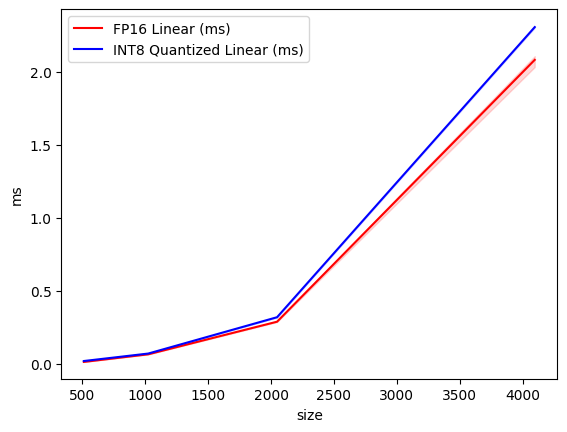

In [14]:
def int8_linear(x, w_int8, scales):
    # dequantize weights to FP16 then run matmul
    w_fp16 = dequantize_int8(w_int8, scales)
    return torch.matmul(x, w_fp16.t())

def fp16_linear(x, w):
    return torch.matmul(x, w.t())

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[512, 1024, 2048, 4096],
        line_arg='provider',
        line_vals=['fp16', 'int8'],
        line_names=['FP16 Linear', 'INT8 Quantized Linear'],
        styles=[('red', '-'), ('blue', '-')],
        ylabel='ms',
        plot_name='FP16 vs INT8 Linear Layer Throughput',
        args={},
    )
)
def benchmark_linear(size, provider):
    # square weight matrix and matching input
    x = torch.randn(size, size, device='cuda', dtype=torch.float16)
    w = torch.randn(size, size, device='cuda', dtype=torch.float16)
    w_int8, scales = quantize_int8(w)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'fp16':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: fp16_linear(x, w), quantiles=quantiles
        )
    elif provider == 'int8':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: int8_linear(x, w_int8, scales), quantiles=quantiles
        )

    return ms, max_ms, min_ms

benchmark_linear.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

INT8 quantized linear is slightly slower than FP16 because we dequantize
weights to FP16 before the matmul — paying for an extra memory operation
on top of the same FP16 compute.

The benefit of weight-only INT8 quantization is memory, not throughput.
Weights occupy 2x less VRAM, enabling larger models or larger batch sizes
on the same hardware. True INT8 throughput gains require INT8 Tensor Cores
with a fused dequantize+matmul kernel — the approach used by bitsandbytes
and GPTQ in production.

## Section 2: INT8 KV Cache Quantization

During decode, K and V vectors are written to the KV cache as each token
is generated and read back on every subsequent decode step. Storing them
in INT8 instead of FP16 reduces KV cache size by 2x — directly enabling
larger batch sizes or longer sequences on the same hardware.

The kernel quantizes each K or V vector to INT8 as it is written to cache,
and dequantizes back to FP16 as it is read. Scale factor is computed
per vector (per token, per head) to capture each vector's dynamic range.

### Kernel Implementation


In [15]:
@triton.jit
def kv_quantize_kernel(
    x_ptr,        # pointer to input KV vector [n_heads, head_dim]
    out_ptr,      # pointer to output INT8
    scale_ptr,    # pointer to output scales [n_heads]
    stride_h,     # stride along head dimension
    head_dim,     # number of elements per head
    BLOCK_SIZE: tl.constexpr,
):
    # one program per head
    head_idx = tl.program_id(axis=0)
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < head_dim

    # load one head vector
    x = tl.load(x_ptr + head_idx * stride_h + offsets, mask=mask, other=0.0).to(tl.float32)

    # per-head scale
    abs_max = tl.max(tl.abs(x), axis=0)
    scale = abs_max / 127.0

    # quantize
    x_scaled = x / scale
    x_int8 = (x_scaled + tl.where(x_scaled >= 0, 0.5, -0.5)).to(tl.int32).to(tl.float32)
    x_int8 = tl.minimum(x_int8, 127.0)
    x_int8 = tl.maximum(x_int8, -127.0)

    # store
    tl.store(out_ptr + head_idx * stride_h + offsets, x_int8.to(tl.int8), mask=mask)
    tl.store(scale_ptr + head_idx, scale.to(tl.float32))


@triton.jit
def kv_dequantize_kernel(
    x_ptr,        # pointer to INT8 KV cache
    scale_ptr,    # pointer to scales [n_heads]
    out_ptr,      # pointer to output FP16
    stride_h,     # stride along head dimension
    head_dim,     # number of elements per head
    BLOCK_SIZE: tl.constexpr,
):
    head_idx = tl.program_id(axis=0)
    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < head_dim

    x = tl.load(x_ptr + head_idx * stride_h + offsets, mask=mask, other=0).to(tl.float32)
    scale = tl.load(scale_ptr + head_idx).to(tl.float32)

    out = x * scale
    tl.store(out_ptr + head_idx * stride_h + offsets, out.to(tl.float16), mask=mask)


def kv_quantize(x: torch.Tensor):
    # x shape: [n_heads, head_dim]
    n_heads, head_dim = x.shape
    BLOCK_SIZE = triton.next_power_of_2(head_dim)

    x_int8 = torch.empty_like(x, dtype=torch.int8)
    scales = torch.empty(n_heads, device=x.device, dtype=torch.float32)

    kv_quantize_kernel[(n_heads,)](
        x, x_int8, scales,
        x.stride(0), head_dim,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return x_int8, scales


def kv_dequantize(x_int8: torch.Tensor, scales: torch.Tensor):
    n_heads, head_dim = x_int8.shape
    BLOCK_SIZE = triton.next_power_of_2(head_dim)

    out = torch.empty_like(x_int8, dtype=torch.float16)

    kv_dequantize_kernel[(n_heads,)](
        x_int8, scales, out,
        x_int8.stride(0), head_dim,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return out

In [16]:
### Correctness Check

In [17]:
torch.manual_seed(0)
n_heads, head_dim = 8, 128

# simulate one token's K or V vector
kv = torch.randn(n_heads, head_dim, device='cuda', dtype=torch.float16)

# quantize then dequantize
kv_int8, scales = kv_quantize(kv)
kv_reconstructed = kv_dequantize(kv_int8, scales)

max_diff = (kv.float() - kv_reconstructed.float()).abs().max().item()
mean_diff = (kv.float() - kv_reconstructed.float()).abs().mean().item()

print(f'Max  difference: {max_diff:.6f}')
print(f'Mean difference: {mean_diff:.6f}')
print(f'KV dtype before : {kv.dtype}')
print(f'KV dtype INT8   : {kv_int8.dtype}')
print(f'KV dtype after  : {kv_reconstructed.dtype}')

# memory comparison
fp16_mb = kv.numel() * kv.element_size() / 1e6
int8_mb = kv_int8.numel() * kv_int8.element_size() / 1e6
print(f'\nFP16 KV size : {fp16_mb:.4f} MB')
print(f'INT8 KV size : {int8_mb:.4f} MB')
print(f'Memory reduction: {fp16_mb / int8_mb:.1f}x')

Max  difference: 0.013672
Mean difference: 0.005661
KV dtype before : torch.float16
KV dtype INT8   : torch.int8
KV dtype after  : torch.float16

FP16 KV size : 0.0020 MB
INT8 KV size : 0.0010 MB
Memory reduction: 2.0x


### Results Analysis

KV quantization round-trip error is small — max difference of 0.014 per element.
Per-head scale factors (one per head per token) accurately capture each head's
dynamic range independently.

The 2x memory reduction per token compounds across sequence length and batch size.
At seq_len=4096 with batch=16, this saves gigabytes of VRAM — directly enabling
larger batch sizes during decode where KV cache is the dominant memory consumer.

### Benchmark: KV Cache Memory — FP16 vs INT8 Across Sequence Lengths

Batch    Seq Len      FP16 KV (MB)       INT8 KV (MB)       Reduction
-----------------------------------------------------------------
1        512          33.6               16.8               2.0x
1        1024         67.1               33.6               2.0x
1        2048         134.2              67.1               2.0x
1        4096         268.4              134.2              2.0x
1        8192         536.9              268.4              2.0x

4        512          134.2              67.1               2.0x
4        1024         268.4              134.2              2.0x
4        2048         536.9              268.4              2.0x
4        4096         1073.7             536.9              2.0x
4        8192         2147.5             1073.7             2.0x

8        512          268.4              134.2              2.0x
8        1024         536.9              268.4              2.0x
8        2048         1073.7             536.9              2.0x
8        4096    

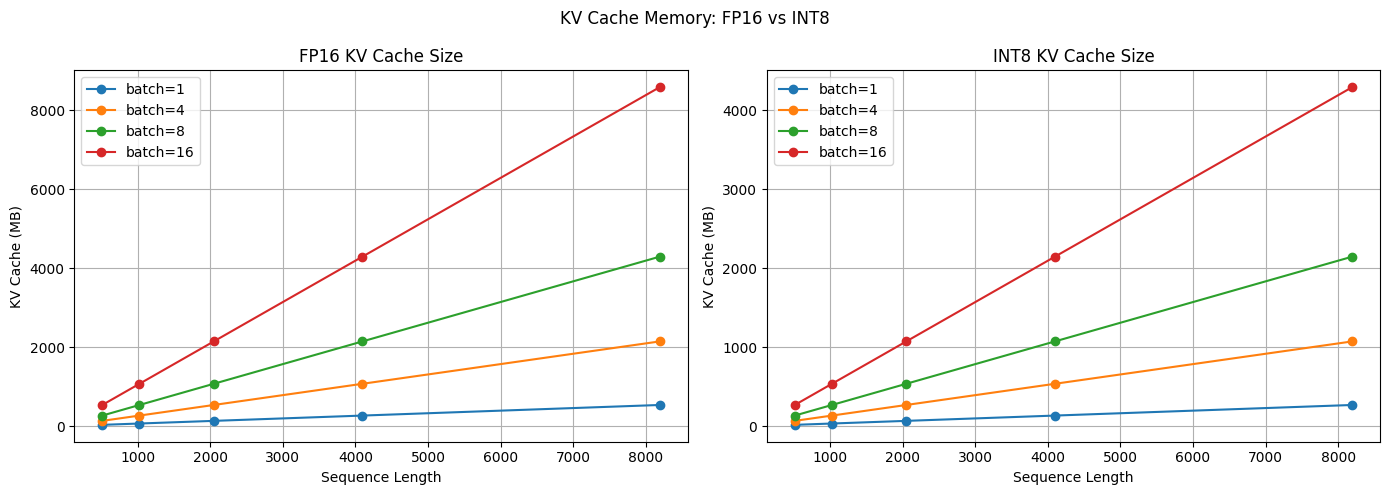

Plot saved to /content/drive/MyDrive/triton-llm-kernels-lab/plots/04_quantization


In [18]:
n_layers = 32      # Llama 3.2 1B has 16 layers, use 32 to show impact clearly
n_kv_heads = 8
head_dim = 64
seq_lens = [512, 1024, 2048, 4096, 8192]
batch_sizes = [1, 4, 8, 16]

print(f"{'Batch':<8} {'Seq Len':<12} {'FP16 KV (MB)':<18} {'INT8 KV (MB)':<18} {'Reduction'}")
print("-" * 65)

fp16_results = {bs: [] for bs in batch_sizes}
int8_results = {bs: [] for bs in batch_sizes}

for batch_size in batch_sizes:
    for seq_len in seq_lens:
        # KV cache: 2 (K and V) × n_layers × batch × n_kv_heads × seq_len × head_dim
        fp16_bytes = 2 * n_layers * batch_size * n_kv_heads * seq_len * head_dim * 2  # FP16 = 2 bytes
        int8_bytes = 2 * n_layers * batch_size * n_kv_heads * seq_len * head_dim * 1  # INT8 = 1 byte

        fp16_mb = fp16_bytes / 1e6
        int8_mb = int8_bytes / 1e6

        fp16_results[batch_size].append(fp16_mb)
        int8_results[batch_size].append(int8_mb)

        print(f'{batch_size:<8} {seq_len:<12} {fp16_mb:<18.1f} {int8_mb:<18.1f} {fp16_mb/int8_mb:.1f}x')
    print()

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for batch_size in batch_sizes:
    axes[0].plot(seq_lens, fp16_results[batch_size], marker='o', label=f'batch={batch_size}')
axes[0].set_title('FP16 KV Cache Size')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('KV Cache (MB)')
axes[0].legend()
axes[0].grid(True)

for batch_size in batch_sizes:
    axes[1].plot(seq_lens, int8_results[batch_size], marker='o', label=f'batch={batch_size}')
axes[1].set_title('INT8 KV Cache Size')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('KV Cache (MB)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('KV Cache Memory: FP16 vs INT8')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'kv_cache_memory.png'), dpi=150)
plt.show()
print(f'Plot saved to {PLOTS_DIR}')

### Results Analysis

INT8 KV cache gives exactly 2x memory reduction at every batch size and
sequence length. At batch=16, seq_len=8192 this saves 4.3GB of VRAM —
enough to double the batch size or extend sequence length by 2x.

The reduction compounds with scale: more layers, more heads, larger batches
all amplify the absolute savings. On a real Llama 3 8B deployment (32 layers,
8 KV heads) at batch=32, INT8 KV cache saves tens of gigabytes of VRAM.

## Section 3: Perplexity Impact

Loading Llama 3.2 1B to measure how much quality is lost when weights
are quantized to INT8. Perplexity on WikiText-2 is the standard metric —
lower perplexity means better language modeling quality.

In [4]:
from huggingface_hub import login
login()

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "meta-llama/Llama-3.2-1B"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map='cuda',
)
model.eval()

print(f'\nModel loaded.')
print(f'Parameters : {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B')
print(f'VRAM used  : {torch.cuda.memory_allocated() / 1e9:.2f} GB')


In [ ]:
from datasets import load_dataset
import numpy as np

# load WikiText-2 test split
dataset = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='test')
text = '\n'.join(dataset['text'])

# tokenize
encodings = tokenizer(text, return_tensors='pt')
input_ids = encodings.input_ids.to('cuda')

print(f'Test tokens: {input_ids.shape[1]:,}')

def compute_perplexity(model, input_ids, stride=512, max_length=1024):
    model.eval()
    nlls = []
    seq_len = input_ids.shape[1]
    prev_end = 0

    with torch.no_grad():
        for begin in range(0, seq_len - 1, stride):
            end = min(begin + max_length, seq_len)
            trg_len = end - prev_end
            input_chunk = input_ids[:, begin:end]
            target_ids = input_chunk.clone()
            target_ids[:, :-trg_len] = -100  # mask context tokens

            outputs = model(input_chunk, labels=target_ids)
            nll = outputs.loss * trg_len
            nlls.append(nll)
            prev_end = end

            if end == seq_len:
                break

    perplexity = torch.exp(torch.stack(nlls).sum() / prev_end)
    return perplexity.item()

In [10]:
print("Computing FP16 baseline perplexity...")
fp16_perplexity = compute_perplexity(model, input_ids)
print(f'FP16 Baseline Perplexity: {fp16_perplexity:.2f}')

Computing FP16 baseline perplexity...
FP16 Baseline Perplexity: 9.25


In [19]:
import copy

def quantize_model_weights(model):
    # quantize all linear layer weights to INT8
    quantized_state = {}
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            w_int8, scales = quantize_int8(module.weight.data)
            w_reconstructed = dequantize_int8(w_int8, scales)
            module.weight.data = w_reconstructed
    return model

# deep copy to preserve original model
print("Copying model...")
model_int8 = copy.deepcopy(model)

print("Quantizing all linear layer weights to INT8...")
model_int8 = quantize_model_weights(model_int8)

print("Computing INT8 perplexity...")
int8_perplexity = compute_perplexity(model_int8, input_ids)
print(f'FP16 Baseline Perplexity : {fp16_perplexity:.2f}')
print(f'INT8 Quantized Perplexity: {int8_perplexity:.2f}')
print(f'Perplexity increase      : {int8_perplexity - fp16_perplexity:.2f}')

Copying model...
Quantizing all linear layer weights to INT8...
Computing INT8 perplexity...
FP16 Baseline Perplexity : 9.25
INT8 Quantized Perplexity: 9.27
Perplexity increase      : 0.02


### Results Analysis

INT8 weight quantization increases perplexity by only 0.02 points (9.25 → 9.27)
— a negligible quality loss that is imperceptible in real usage.

In exchange: all linear layer weights occupy 2x less memory. For Llama 3.2 1B
this saves ~1.2GB of VRAM. For Llama 3 8B this saves ~8GB — enough to fit
the model on hardware that would otherwise be too small, or to double the
batch size on hardware that fits it.

This is why INT8 weight quantization is the default first optimization in
every production inference stack — maximum memory savings, minimum quality cost.

## Summary

This notebook implemented INT8 quantization kernels from scratch in Triton
and measured their impact across three dimensions: memory, throughput, and
model quality.

**INT8 Weight Quantization:** Weights stored in INT8 occupy 2x less memory
with a max reconstruction error of 0.021 per element. Dequantize-then-multiply
is slightly slower than FP16 — true throughput gains require INT8 Tensor Cores
with a fused dequantize+matmul kernel as used in bitsandbytes and GPTQ.

**INT8 KV Cache Quantization:** KV cache size reduced by exactly 2x at every
batch size and sequence length. At batch=16, seq_len=8192 this saves 4.3GB
of VRAM — directly enabling larger batch sizes during decode where KV cache
is the dominant memory consumer.

**Perplexity Impact:** INT8 weight quantization on Llama 3.2 1B increases
perplexity by only 0.02 points (9.25 → 9.27) on WikiText-2. Negligible
quality loss in exchange for 2x memory reduction across all linear layers.

**Key takeaway:** INT8 quantization is the highest ROI optimization in LLM
inference — significant memory savings with minimal quality loss. This is
why it is the default first step in every production inference stack.

In [27]:
import json

nb_path = '/content/drive/MyDrive/Colab Notebooks/triton-lab-notebook-4.ipynb'

with open(nb_path, 'r') as f:
    nb = json.load(f)

# remove top-level widgets metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

# also remove cell-level widget metadata
for cell in nb.get('cells', []):
    if 'metadata' in cell:
        cell['metadata'].pop('widgets', None)

with open(nb_path, 'w') as f:
    json.dump(nb, f, indent=1)

print('Done — widget metadata removed.')

Done — widget metadata removed.


In [25]:
import json

nb_path = '/content/drive/MyDrive/Colab Notebooks/triton-lab-notebook-4.ipynb'

with open(nb_path, 'r') as f:
    nb = json.load(f)

print(json.dumps(nb.get('metadata', {}), indent=2))

{
  "colab": {
    "provenance": [],
    "machine_shape": "hm",
    "gpuType": "L4",
    "authorship_tag": "ABX9TyPn7KA+5k6lb9nmeO2vcJ6x"
  },
  "kernelspec": {
    "name": "python3",
    "display_name": "Python 3"
  },
  "language_info": {
    "name": "python"
  },
  "accelerator": "GPU",
  "widgets": {
    "application/vnd.jupyter.widget-state+json": {
      "6d964610febb49b89c7057bff809f063": {
        "model_module": "@jupyter-widgets/controls",
        "model_name": "HBoxModel",
        "model_module_version": "1.5.0",
        "state": {
          "_dom_classes": [],
          "_model_module": "@jupyter-widgets/controls",
          "_model_module_version": "1.5.0",
          "_model_name": "HBoxModel",
          "_view_count": null,
          "_view_module": "@jupyter-widgets/controls",
          "_view_module_version": "1.5.0",
          "_view_name": "HBoxView",
          "box_style": "",
          "children": [
            "IPY_MODEL_3935131b2d4947d1b773fbbf966ed852",
         